In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('glassdoor_cleaned.csv')

In [4]:
df

,Company,Job_Ratings,Job_Title,Application_Link,Job_Tracking,Offer_age,City,State,Hourly,Min_Pay,Max_Pay,Average_Pay
0,Ramp Financial,4.1,Summer 2025 | Applied Scientist Intern,https://www.glassdoor.com/job-listing/summer-2...,https://www.glassdoor.com/partner/jobListing.h...,30d+,New York,NY,1,62.5,62.5,62.50
1,Vertex Pharmaceuticals,4.2,"Vertex Summer 2025 Intern, Pharmacology (San D...",https://www.glassdoor.com/job-listing/vertex-s...,https://www.glassdoor.com/partner/jobListing.h...,3d,San Diego,CA,1,33.0,50.0,41.50
2,Pape-Dawson Engineers,4.1,Internship Summer 2025 - Biologist Intern,https://www.glassdoor.com/job-listing/internsh...,https://www.glassdoor.com/partner/jobListing.h...,16d,Austin,TX,0,36.0,52.0,44.00
3,Coeur Mining,4.0,INTERN - Geology (Summer 2025),https://www.glassdoor.com/job-listing/intern-g...,https://www.glassdoor.com/partner/jobListing.h...,30d+,Lovelock,NV,1,27.5,27.5,27.50
4,Expedia Group,3.8,Machine Learning Scientist Intern - Masters - ...,https://www.glassdoor.com/job-listing/machine-...,https://www.glassdoor.com/partner/jobListing.h...,30d+,Seattle,WA,1,50.0,50.0,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Omaha's Henry Doorly Zoo and Aquarium,3.4,Sea Lions Intern,https://www.glassdoor.com/job-listing/sea-lion...,https://www.glassdoor.com/partner/jobListing.h...,19d,Omaha,NE,1,13.5,13.5,13.50
424,Omaha's Henry Doorly Zoo and Aquarium,3.4,Behavioral Husbandry and Wellbeing Intern,https://www.glassdoor.com/job-listing/behavior...,https://www.glassdoor.com/partner/jobListing.h...,18d,Omaha,NE,1,13.5,13.5,13.50
425,State of North Carolina,3.8,State of NC Internship - Aquarium Animal Husba...,https://www.glassdoor.com/job-listing/state-of...,https://www.glassdoor.com/partner/jobListing.h...,4d,United States,NaN,1,15.0,15.0,15.00
426,E. & J. Gallo,4.3,"Chemistry, Biology and Sensory Research Intern...",https://www.glassdoor.com/job-listing/chemistr...,https://www.glassdoor.com/partner/jobListing.h...,28d,Modesto,CA,1,22.5,26.0,24.25


In [5]:
df['Offer_age'] = df['Offer_age'].str.replace(r'd|\+', '', regex=True)

In [6]:
df

,Company,Job_Ratings,Job_Title,Application_Link,Job_Tracking,Offer_age,City,State,Hourly,Min_Pay,Max_Pay,Average_Pay
0,Ramp Financial,4.1,Summer 2025 | Applied Scientist Intern,https://www.glassdoor.com/job-listing/summer-2...,https://www.glassdoor.com/partner/jobListing.h...,30,New York,NY,1,62.5,62.5,62.50
1,Vertex Pharmaceuticals,4.2,"Vertex Summer 2025 Intern, Pharmacology (San D...",https://www.glassdoor.com/job-listing/vertex-s...,https://www.glassdoor.com/partner/jobListing.h...,3,San Diego,CA,1,33.0,50.0,41.50
2,Pape-Dawson Engineers,4.1,Internship Summer 2025 - Biologist Intern,https://www.glassdoor.com/job-listing/internsh...,https://www.glassdoor.com/partner/jobListing.h...,16,Austin,TX,0,36.0,52.0,44.00
3,Coeur Mining,4.0,INTERN - Geology (Summer 2025),https://www.glassdoor.com/job-listing/intern-g...,https://www.glassdoor.com/partner/jobListing.h...,30,Lovelock,NV,1,27.5,27.5,27.50
4,Expedia Group,3.8,Machine Learning Scientist Intern - Masters - ...,https://www.glassdoor.com/job-listing/machine-...,https://www.glassdoor.com/partner/jobListing.h...,30,Seattle,WA,1,50.0,50.0,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Omaha's Henry Doorly Zoo and Aquarium,3.4,Sea Lions Intern,https://www.glassdoor.com/job-listing/sea-lion...,https://www.glassdoor.com/partner/jobListing.h...,19,Omaha,NE,1,13.5,13.5,13.50
424,Omaha's Henry Doorly Zoo and Aquarium,3.4,Behavioral Husbandry and Wellbeing Intern,https://www.glassdoor.com/job-listing/behavior...,https://www.glassdoor.com/partner/jobListing.h...,18,Omaha,NE,1,13.5,13.5,13.50
425,State of North Carolina,3.8,State of NC Internship - Aquarium Animal Husba...,https://www.glassdoor.com/job-listing/state-of...,https://www.glassdoor.com/partner/jobListing.h...,4,United States,NaN,1,15.0,15.0,15.00
426,E. & J. Gallo,4.3,"Chemistry, Biology and Sensory Research Intern...",https://www.glassdoor.com/job-listing/chemistr...,https://www.glassdoor.com/partner/jobListing.h...,28,Modesto,CA,1,22.5,26.0,24.25


In [7]:
df.Min_Pay = df.apply(lambda x: x.Min_Pay*2 if x.Hourly ==1 else x.Min_Pay, axis=1)
df.Max_Pay = df.apply(lambda x: x.Max_Pay*2 if x.Hourly ==1 else x.Max_Pay, axis=1)
df.Average_Pay = df.apply(lambda x: x.Average_Pay*2 if x.Hourly ==1 else x.Average_Pay, axis=1)
df

,Company,Job_Ratings,Job_Title,Application_Link,Job_Tracking,Offer_age,City,State,Hourly,Min_Pay,Max_Pay,Average_Pay
0,Ramp Financial,4.1,Summer 2025 | Applied Scientist Intern,https://www.glassdoor.com/job-listing/summer-2...,https://www.glassdoor.com/partner/jobListing.h...,30,New York,NY,1,125.0,125.0,125.0
1,Vertex Pharmaceuticals,4.2,"Vertex Summer 2025 Intern, Pharmacology (San D...",https://www.glassdoor.com/job-listing/vertex-s...,https://www.glassdoor.com/partner/jobListing.h...,3,San Diego,CA,1,66.0,100.0,83.0
2,Pape-Dawson Engineers,4.1,Internship Summer 2025 - Biologist Intern,https://www.glassdoor.com/job-listing/internsh...,https://www.glassdoor.com/partner/jobListing.h...,16,Austin,TX,0,36.0,52.0,44.0
3,Coeur Mining,4.0,INTERN - Geology (Summer 2025),https://www.glassdoor.com/job-listing/intern-g...,https://www.glassdoor.com/partner/jobListing.h...,30,Lovelock,NV,1,55.0,55.0,55.0
4,Expedia Group,3.8,Machine Learning Scientist Intern - Masters - ...,https://www.glassdoor.com/job-listing/machine-...,https://www.glassdoor.com/partner/jobListing.h...,30,Seattle,WA,1,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Omaha's Henry Doorly Zoo and Aquarium,3.4,Sea Lions Intern,https://www.glassdoor.com/job-listing/sea-lion...,https://www.glassdoor.com/partner/jobListing.h...,19,Omaha,NE,1,27.0,27.0,27.0
424,Omaha's Henry Doorly Zoo and Aquarium,3.4,Behavioral Husbandry and Wellbeing Intern,https://www.glassdoor.com/job-listing/behavior...,https://www.glassdoor.com/partner/jobListing.h...,18,Omaha,NE,1,27.0,27.0,27.0
425,State of North Carolina,3.8,State of NC Internship - Aquarium Animal Husba...,https://www.glassdoor.com/job-listing/state-of...,https://www.glassdoor.com/partner/jobListing.h...,4,United States,NaN,1,30.0,30.0,30.0
426,E. & J. Gallo,4.3,"Chemistry, Biology and Sensory Research Intern...",https://www.glassdoor.com/job-listing/chemistr...,https://www.glassdoor.com/partner/jobListing.h...,28,Modesto,CA,1,45.0,52.0,48.5


In [8]:
row_numbers_h = df.index[df['Offer_age'].str.contains('h')].tolist()
print(row_numbers_h)

[7, 8, 15, 18, 25, 42, 60, 101, 137, 166, 167, 176, 210, 238]


In [9]:
df.drop(row_numbers_h, inplace=True)

In [10]:
df[['Job_Ratings', 'Average_Pay', 'Offer_age']].corr()

,Job_Ratings,Average_Pay,Offer_age
Job_Ratings,1.000000,0.168932,-0.076340
Average_Pay,0.168932,1.000000,0.097289
Offer_age,-0.076340,0.097289,1.000000


<Axes: >

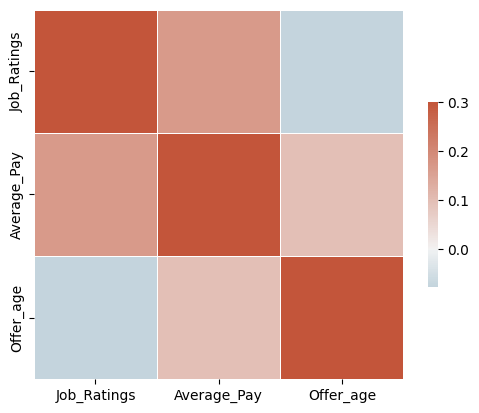

In [11]:
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(df[['Job_Ratings', 'Average_Pay', 'Offer_age']].corr(), 
            vmax=.3, center=0, cmap=cmap,  # Use the custom diverging palette
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [12]:
pivot_table = df.pivot_table(index='State', values='Job_Title', aggfunc='count')
pivot_table = pivot_table.sort_values(by='Job_Title', ascending=False)
pivot_table

,Job_Title
State,
CA,65
NJ,34
MA,33
IL,27
WI,17
MN,16
WA,15
OH,15
TX,14


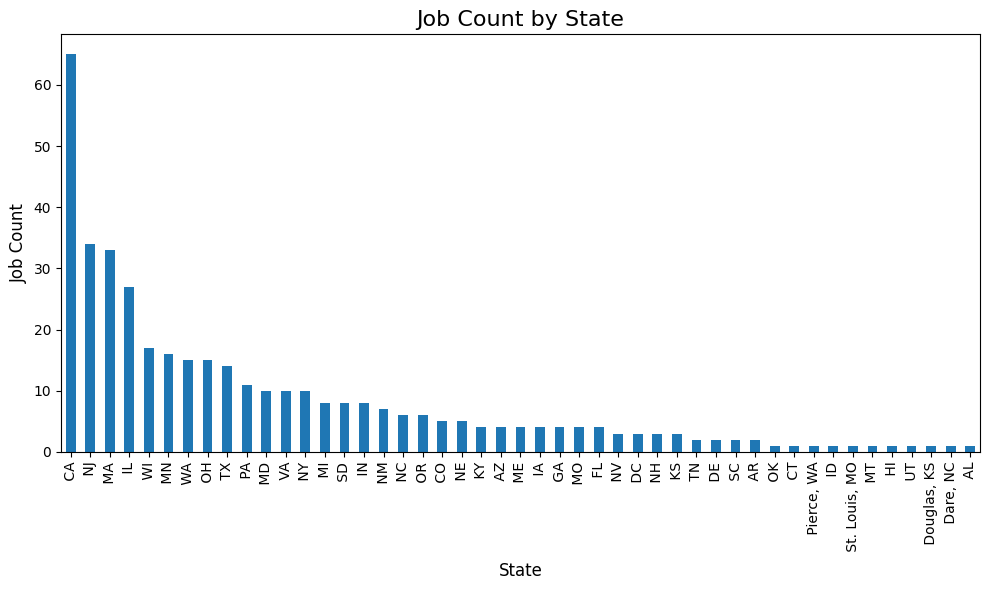

In [13]:
import matplotlib.pyplot as plt

# Plotting a bar chart
pivot_table.plot(kind='bar', legend=False, figsize=(10, 6))

# Customizing the plot
plt.title('Job Count by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Job Count', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout for better fit
plt.show()


In [14]:
pivot_table2 = df.pivot_table(index='State', values='Average_Pay', aggfunc='mean')
pivot_table2 = pivot_table2.sort_values(by='Average_Pay', ascending=False)
pivot_table2

,Average_Pay
State,
MA,91.130435
DE,83.250000
NJ,80.356500
HI,80.000000
NM,78.833333
NY,76.642857
IL,75.720000
CA,75.544211
KY,70.000000


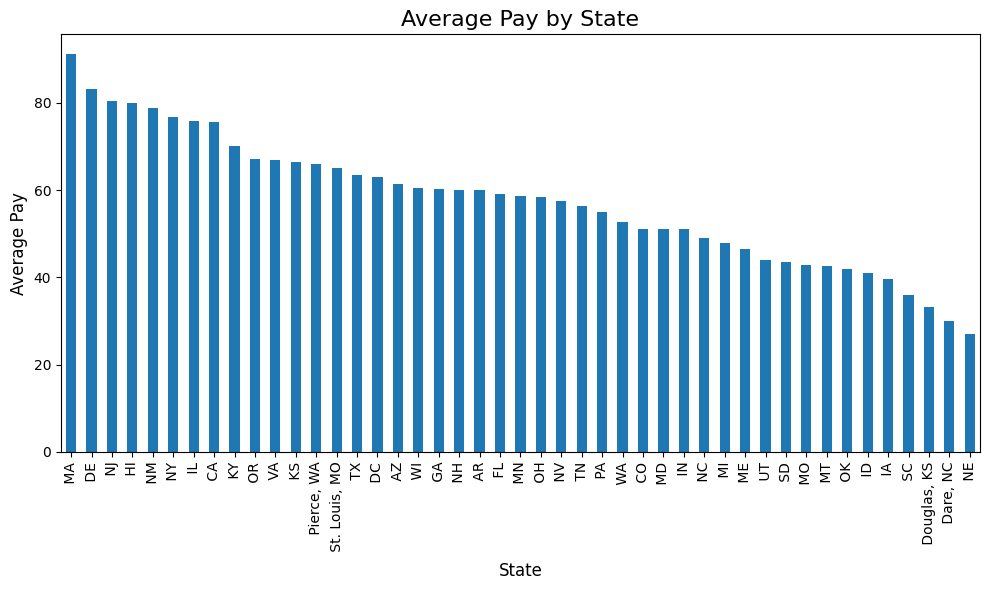

In [15]:
# Plotting a bar chart
pivot_table2.plot(kind='bar', legend=False, figsize=(10, 6))

# Customizing the plot
plt.title('Average Pay by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Pay', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout for better fit
plt.show()


In [16]:
df.columns


Index(['Company', 'Job_Ratings', 'Job_Title', 'Application_Link',
       'Job_Tracking', 'Offer_age', 'City', 'State', 'Hourly', 'Min_Pay',
       'Max_Pay', 'Average_Pay'],
      dtype='object')

In [17]:
# Define job roles
Job_role = ['Research', 'Analyst', 'Scientist', 'Machine Learning']

# Loop through the job roles and calculate counts
for role in Job_role:
    count = df['Job_Title'].str.contains(role, case=False, na=False).sum()
    print(f"{role}: {count}")


Research: 110
Analyst: 9
Scientist: 27
Machine Learning: 4


In [18]:
df

,Company,Job_Ratings,Job_Title,Application_Link,Job_Tracking,Offer_age,City,State,Hourly,Min_Pay,Max_Pay,Average_Pay
0,Ramp Financial,4.1,Summer 2025 | Applied Scientist Intern,https://www.glassdoor.com/job-listing/summer-2...,https://www.glassdoor.com/partner/jobListing.h...,30,New York,NY,1,125.0,125.0,125.0
1,Vertex Pharmaceuticals,4.2,"Vertex Summer 2025 Intern, Pharmacology (San D...",https://www.glassdoor.com/job-listing/vertex-s...,https://www.glassdoor.com/partner/jobListing.h...,3,San Diego,CA,1,66.0,100.0,83.0
2,Pape-Dawson Engineers,4.1,Internship Summer 2025 - Biologist Intern,https://www.glassdoor.com/job-listing/internsh...,https://www.glassdoor.com/partner/jobListing.h...,16,Austin,TX,0,36.0,52.0,44.0
3,Coeur Mining,4.0,INTERN - Geology (Summer 2025),https://www.glassdoor.com/job-listing/intern-g...,https://www.glassdoor.com/partner/jobListing.h...,30,Lovelock,NV,1,55.0,55.0,55.0
4,Expedia Group,3.8,Machine Learning Scientist Intern - Masters - ...,https://www.glassdoor.com/job-listing/machine-...,https://www.glassdoor.com/partner/jobListing.h...,30,Seattle,WA,1,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Omaha's Henry Doorly Zoo and Aquarium,3.4,Sea Lions Intern,https://www.glassdoor.com/job-listing/sea-lion...,https://www.glassdoor.com/partner/jobListing.h...,19,Omaha,NE,1,27.0,27.0,27.0
424,Omaha's Henry Doorly Zoo and Aquarium,3.4,Behavioral Husbandry and Wellbeing Intern,https://www.glassdoor.com/job-listing/behavior...,https://www.glassdoor.com/partner/jobListing.h...,18,Omaha,NE,1,27.0,27.0,27.0
425,State of North Carolina,3.8,State of NC Internship - Aquarium Animal Husba...,https://www.glassdoor.com/job-listing/state-of...,https://www.glassdoor.com/partner/jobListing.h...,4,United States,NaN,1,30.0,30.0,30.0
426,E. & J. Gallo,4.3,"Chemistry, Biology and Sensory Research Intern...",https://www.glassdoor.com/job-listing/chemistr...,https://www.glassdoor.com/partner/jobListing.h...,28,Modesto,CA,1,45.0,52.0,48.5


In [19]:
Job_role = ['Research', 'Analyst', 'Scientist', 'Machine Learning']

# Calculate average pay for each role
for role in Job_role:
    role_filter = df['Job_Title'].str.contains(role, case=False, na=False)
    avg_pay = df.loc[role_filter, 'Average_Pay'].mean()
    print(f"{role}: Average Pay = ${avg_pay:.2f}")

Research: Average Pay = $74.19
Analyst: Average Pay = $79.36
Scientist: Average Pay = $77.52
Machine Learning: Average Pay = $107.38


In [20]:
Job_role = ['Research', 'Analyst', 'Scientist', 'Machine Learning']

for role in Job_role:
    role_filter = df['Job_Title'].str.contains(role, case=False, na=False).sum()
    print(f"{role}: {role_filter}")


Research: 110
Analyst: 9
Scientist: 27
Machine Learning: 4


In [21]:
# Calculate min, max, and average pay for each role
for role in Job_role:
    role_filter = df['Job_Title'].str.contains(role, case=False, na=False)
    min_pay = df.loc[role_filter, 'Min_Pay'].mean()
    max_pay = df.loc[role_filter, 'Max_Pay'].mean()
    avg_pay = df.loc[role_filter, 'Average_Pay'].mean()
    print(f"{role}: Min Pay = ${min_pay:.2f}, Max Pay = ${max_pay:.2f}, Average Pay = ${avg_pay:.2f}")

Research: Min Pay = $60.91, Max Pay = $87.46, Average Pay = $74.19
Analyst: Min Pay = $72.71, Max Pay = $86.00, Average Pay = $79.36
Scientist: Min Pay = $64.89, Max Pay = $90.15, Average Pay = $77.52
Machine Learning: Min Pay = $83.81, Max Pay = $130.95, Average Pay = $107.38


In [22]:
df.to_csv('glassdoor_cleaned2.csv', index=False)